# Bước 4 — Demand model: P(book | price, context)

**Mục tiêu**: train classifier dự đoán xác suất booking xảy ra trong window snapshot kế tiếp, given current state + price ứng viên.

**Models**:
- **LogReg baseline** — interpretable, signed coefficient cho price = elasticity direction
- **LightGBM production** — capture non-linear + interaction

**Caveat quan trọng** (ROADMAP §3 Bước 4): data chỉ có giá thực tế đã set, không có counterfactual ("nếu set giá khác thì sao"). Model học CORRELATION, chưa hẳn CAUSAL. Đây là *predictive demand model*, không phải *causal price elasticity*. Phase 2 cần A/B test thật để validate.

**Time split**: theo `updated_date` (thời điểm predict), KHÔNG theo `date` (stay_date). Lý do: Sale team flow là "tại time T predict booking next snapshot" — split theo `updated_date` mô phỏng đúng deployment.

Deliverable: 2 file `models/demand_{logreg,lgbm}.joblib` + demand curve plot.

## 1. Setup

In [1]:
from pathlib import Path
import sys, warnings

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

## 2. Load features + verify class balance

In [2]:
from src.demand import (
    DEFAULT_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    prepare_X_y, time_split, DemandModel, train_all, MODELS_DIR,
)

df = pd.read_parquet(DEFAULT_FEATURES)
print(f'shape: {df.shape}')
print(f"did_book: {df['did_book'].value_counts(dropna=False).to_dict()}")
print(f"updated_date range: {df['updated_date'].min().date()} → {df['updated_date'].max().date()}")

shape: (46480, 27)
did_book: {0: 42344, 1: 3086, <NA>: 1050}
updated_date range: 2026-01-02 → 2026-05-04


## 3. Time split — verify train/test cùng có positive examples

In [3]:
train_df, test_df = time_split(df, holdout_days=30)
X_train, y_train = prepare_X_y(train_df)
X_test, y_test = prepare_X_y(test_df)

print(f'Train updated_date: {train_df["updated_date"].min().date()} → {train_df["updated_date"].max().date()}')
print(f'Test  updated_date: {test_df["updated_date"].min().date()} → {test_df["updated_date"].max().date()}')
print()
print(f'X_train: {X_train.shape}, positives: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'X_test : {X_test.shape}, positives: {y_test.sum()} ({y_test.mean()*100:.2f}%)')
print()
print('Feature columns:', list(X_train.columns))

Train updated_date: 2026-01-02 → 2026-04-04
Test  updated_date: 2026-04-05 → 2026-05-04

X_train: (34540, 12), positives: 2501 (7.24%)
X_test : (10890, 12), positives: 585 (5.37%)

Feature columns: ['price', 'occupancy_pct', 'available_pct', 'lead_time_days', 'is_weekend', 'is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'room_type_segment_High', 'room_type_segment_Mid']


## 4. Train cả 2 models qua `train_all()`

Metrics:
- **AUC** (ROC): khả năng rank positive cao hơn negative. 0.5 = random, 1.0 = perfect. >0.7 = decent, >0.8 = good.
- **Average Precision** (AP / PR-AUC): tốt cho imbalanced data. Cao = positives được rank đầu.
- **Brier score**: MSE của prob prediction vs actual. CÀNG NHỎ CÀNG TỐT (well-calibrated).

In [4]:
metrics = train_all(holdout_days=30)
metrics

,kind,n_train,n_test,pos_rate_train,pos_rate_test,auc_train,auc_test,avg_prec_test,brier_test,path
0,logreg,34540,10890,0.072409,0.053719,0.867554,0.880315,0.283443,0.183963,models/demand_logreg.joblib
1,lgbm,34540,10890,0.072409,0.053719,0.952905,0.879686,0.341652,0.110059,models/demand_lgbm.joblib


### Đọc metrics

- `auc_train` vs `auc_test`: LGBM train cao hơn test → overfit nhẹ; LogReg cân bằng hơn.
- `avg_prec_test`: LGBM > LogReg → LGBM rank positive tốt hơn.
- `brier_test`: LogReg cao do `class_weight='balanced'` đẩy prob về phía 0.5 (overconfident on positives). LGBM `is_unbalance=True` calibrate tốt hơn.

## 5. ⭐ LogReg coefficients — verify elasticity direction

**Câu hỏi quan trọng nhất của Bước 4**: model có học được "giá tăng → P(book) giảm" không?

Coefficient của `price` PHẢI âm. Nếu dương → model không bắt được elasticity → demand curve sẽ flat hoặc upward sloping → pricing optimization vô nghĩa.

In [5]:
logreg = DemandModel.load(MODELS_DIR / 'demand_logreg.joblib')
coefs = logreg.coefficients()

print('=== LogReg coefficients (post-StandardScaler, sorted) ===')
print(coefs.round(3))
print()
price_coef = coefs['price']
print(f'→ price coef = {price_coef:+.3f}  ({"✓ ÂM (elasticity OK)" if price_coef < 0 else "✗ DƯƠNG (BAD)"})')

=== LogReg coefficients (post-StandardScaler, sorted) ===
lead_time_days           -1.726
available_pct            -1.639
occupancy_pct            -1.547
room_type_segment_High   -0.463
room_type_segment_Mid    -0.433
price                    -0.212
dow_cos                  -0.130
dow_sin                  -0.055
month_sin                -0.044
month_cos                 0.027
is_weekend                0.030
is_holiday                0.052
dtype: float64

→ price coef = -0.212  (✓ ÂM (elasticity OK))


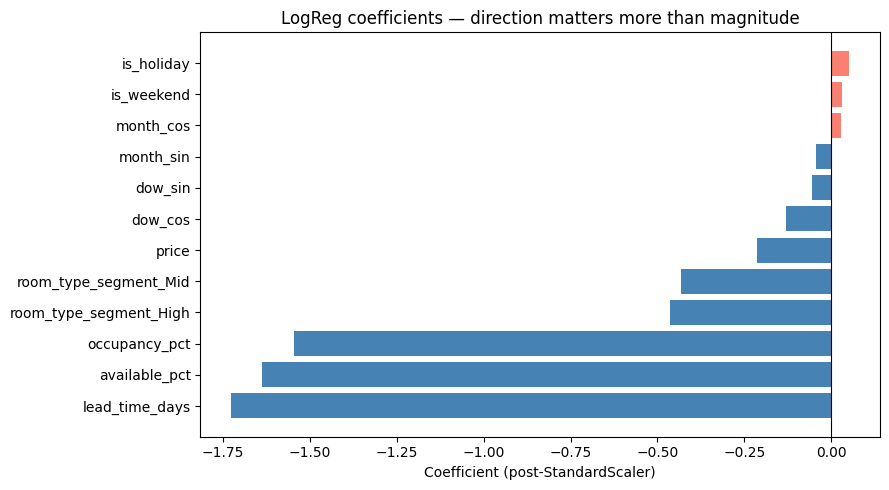

In [6]:
# Visualize coefficients
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if c < 0 else 'salmon' for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (post-StandardScaler)')
ax.set_title('LogReg coefficients — direction matters more than magnitude')
plt.tight_layout(); plt.show()

**Đọc các coef khác** (để hiểu model học gì):

| Feature | Sign | Interpretation |
|---|---|---|
| `lead_time_days` | (−) | Càng gần stay date, càng nhiều booking (last-minute) |
| `available_pct` | (−) | Phòng còn nhiều = ít urgency, ít booking ngay |
| `occupancy_pct` | (−) | Phòng đã book nhiều = saturation, ít chỗ thêm |
| `price` | **(−)** | **Giá ↑ → P(book) ↓ — ELASTICITY ĐÚNG CHIỀU ✓** |
| `segment_High/Mid` | (−) | Entry segment (baseline) book nhiều nhất |
| `is_weekend/holiday` | (+) | Weekend & holiday rate cao hơn weekday |

## 6. Calibration: predicted prob có khớp actual rate không?

Bin predicted prob thành 10 buckets, tính actual positive rate per bucket. Well-calibrated model → đường gần diagonal.

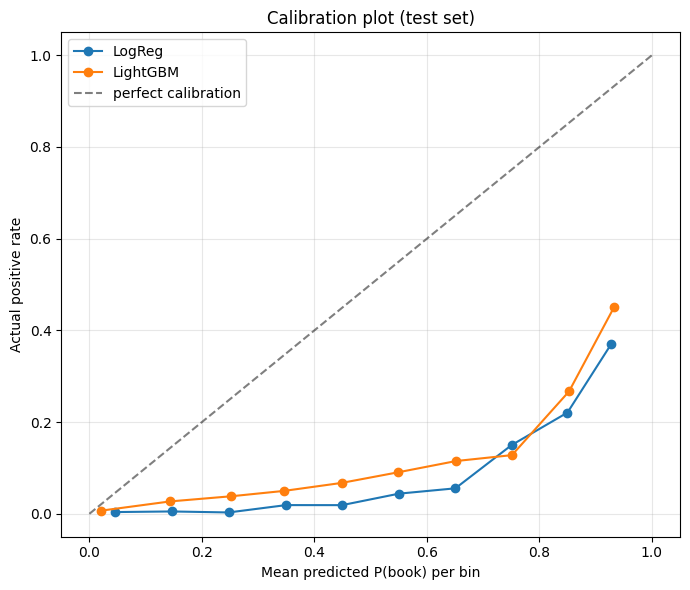

In [7]:
lgbm = DemandModel.load(MODELS_DIR / 'demand_lgbm.joblib')

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in [('LogReg', logreg), ('LightGBM', lgbm)]:
    proba = model.predict_proba(X_test)
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(proba, bins) - 1
    idx = np.clip(idx, 0, 9)
    pred_mean = [proba[idx == k].mean() if (idx == k).sum() > 0 else np.nan for k in range(10)]
    actual_rate = [y_test.values[idx == k].mean() if (idx == k).sum() > 0 else np.nan for k in range(10)]
    ax.plot(pred_mean, actual_rate, 'o-', label=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
ax.set_xlabel('Mean predicted P(book) per bin')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration plot (test set)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. ⭐ Demand curve — vary `price`, see `P(book)` change

**Câu hỏi**: cho 1 context cố định (cùng room_type, stay_date, lead_time, occupancy), nếu thay đổi `price`, P(book) thay đổi thế nào?

Đây là **đường demand curve**, là input chính của Bước 5 (pricing optimization). Expected revenue = `price × P(book)`. Max ở đâu = optimal price.

**Caveat counterfactual**: model chỉ thấy giá thực tế đã set. Khi ta dịch chuyển ra ngoài range historical price, prediction là extrapolation — không trust được hoàn toàn.

In [8]:
# Pick 1 representative snapshot từ test set
sample_row = test_df.iloc[5000:5001].copy()   # 1 snapshot
print('=== Context được hold cố định ===')
print(sample_row[['date', 'updated_date', 'room_type_name', 'lead_time_days',
                   'occupancy_pct', 'available_pct', 'is_weekend',
                   'is_holiday', 'price']].T)

=== Context được hold cố định ===
                                        24996
date                      2026-05-03 00:00:00
updated_date              2026-04-09 00:00:00
room_type_name  Deluxe with banquette seating
lead_time_days                             24
occupancy_pct                             0.7
available_pct                             0.3
is_weekend                                  1
is_holiday                                  0
price                               2650000.0


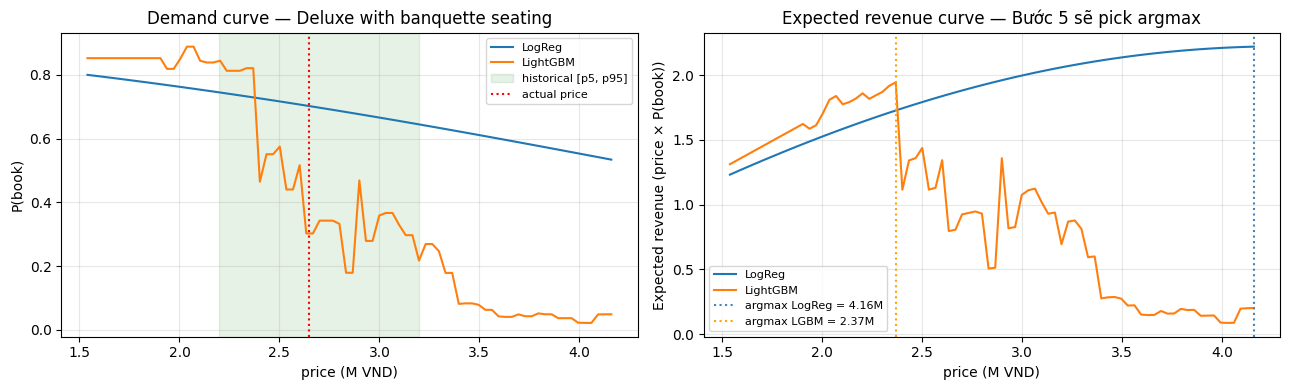

In [9]:
# Vary price across a grid quanh historical range
rt = sample_row['room_type_name'].iloc[0]
hist_min = df.loc[df['room_type_name'] == rt, 'price'].quantile(0.05)
hist_max = df.loc[df['room_type_name'] == rt, 'price'].quantile(0.95)
price_grid = np.linspace(hist_min * 0.7, hist_max * 1.3, 80)

# Build candidate rows: lặp sample_row, thay price
candidates = pd.concat([sample_row.assign(price=p) for p in price_grid], ignore_index=True)
X_cand, _ = prepare_X_y(candidates.assign(did_book=0))  # did_book dummy để pass NA filter

# Reindex columns to match training schema
X_cand = X_cand.reindex(columns=X_train.columns, fill_value=0)

p_logreg = logreg.predict_proba(X_cand)
p_lgbm = lgbm.predict_proba(X_cand)

exp_rev_logreg = price_grid * p_logreg
exp_rev_lgbm = price_grid * p_lgbm

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(price_grid / 1e6, p_logreg, label='LogReg')
axes[0].plot(price_grid / 1e6, p_lgbm, label='LightGBM')
axes[0].axvspan(hist_min / 1e6, hist_max / 1e6, alpha=0.1, color='green',
                 label='historical [p5, p95]')
axes[0].axvline(sample_row['price'].iloc[0] / 1e6, color='red', linestyle=':', label='actual price')
axes[0].set_xlabel('price (M VND)'); axes[0].set_ylabel('P(book)')
axes[0].set_title(f'Demand curve — {rt}')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(price_grid / 1e6, exp_rev_logreg / 1e6, label='LogReg')
axes[1].plot(price_grid / 1e6, exp_rev_lgbm / 1e6, label='LightGBM')
opt_logreg = price_grid[np.argmax(exp_rev_logreg)]
opt_lgbm = price_grid[np.argmax(exp_rev_lgbm)]
axes[1].axvline(opt_logreg / 1e6, color='steelblue', linestyle=':',
                 label=f'argmax LogReg = {opt_logreg/1e6:.2f}M')
axes[1].axvline(opt_lgbm / 1e6, color='orange', linestyle=':',
                 label=f'argmax LGBM = {opt_lgbm/1e6:.2f}M')
axes[1].set_xlabel('price (M VND)'); axes[1].set_ylabel('Expected revenue (price × P(book))')
axes[1].set_title('Expected revenue curve — Bước 5 sẽ pick argmax')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

**Đọc curve**:
- LogReg: smooth, monotonic decreasing P(book) → expected revenue có hình parabol đẹp, optimum rõ.
- LightGBM: bậc thang (tree-based), có thể non-monotonic ở vài chỗ — cần smoothing hoặc constraint monotonic nếu deploy.
- Vùng outside historical [p5, p95] → trust thấp (extrapolation), Bước 5 sẽ clip price_grid trong range hợp lý.

## 8. Caveats + Insights cho Bước 5

### Limitations
1. **Predictive, không phải causal** — model học giá nào hay xuất hiện cùng booking, không phải "nếu đổi giá thì booking đổi sao". Phase 2: A/B test để có causal estimate.
2. **Test AUC ~0.88 nghe đẹp nhưng**: data có pattern mạnh (lead_time, occupancy) — model có thể learn pattern này thay vì price elasticity. Coefficient `price` chỉ -0.21 (yếu so với lead_time -1.7) → elasticity signal là weak signal.
3. **LGBM curve non-monotonic** ở vài region — có thể cần `monotone_constraints={'price': -1}` cho LGBM ở Bước 5.
4. **Out-of-distribution price** → extrapolation. Pricing optimizer phải clip grid trong [historical p5, p95] hoặc [forecast.p10 × 0.7, forecast.p90 × 1.3] (ROADMAP §3 Bước 5).

### Connection sang Bước 5 (Pricing optimization)
```python
def optimize_price(features_row, forecast_model, demand_model, price_grid=None):
    # 1. price_grid từ forecast CI band
    # 2. cho mỗi price, build candidate row, predict_proba → P(book)
    # 3. expected_revenue = price × P(book)
    # 4. return argmax
```

Bước này đã được demo trong Section 7 — Bước 5 sẽ gói thành function với edge case handling.